In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# ==========================================
# Task 7: Time Series Analysis
# Dataset: Stock Market Dataset
# ==========================================

# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings('ignore')

In [2]:


# ------------------------------------------
# Load Dataset
# ------------------------------------------

import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/jacksoncrow/stock-market-dataset/symbols_valid_meta.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/stocks/MTL.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/stocks/JOE.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/stocks/DRE.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/stocks/CTY.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/stocks/AMSF.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/stocks/IMH.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/stocks/GFL.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/stocks/CLM.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/stocks/UBER.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/stocks/NEBU.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/stocks/SGB.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/stocks/WWW.csv
/kaggle/input/datasets/jacksoncrow/stock-market-dataset/stocks/UTS

In [3]:


# Load dataset

df = pd.read_csv('/kaggle/input/datasets/jacksoncrow/stock-market-dataset/stocks/AAPL.csv')

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (9909, 7)

Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

First 5 Rows:
         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.513393  0.515625  0.513393  0.513393   0.406782  117258400
1  1980-12-15  0.488839  0.488839  0.486607  0.486607   0.385558   43971200
2  1980-12-16  0.453125  0.453125  0.450893  0.450893   0.357260   26432000
3  1980-12-17  0.462054  0.464286  0.462054  0.462054   0.366103   21610400
4  1980-12-18  0.475446  0.477679  0.475446  0.475446   0.376715   18362400


In [4]:
print(df.info())


print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9909 non-null   object 
 1   Open       9909 non-null   float64
 2   High       9909 non-null   float64
 3   Low        9909 non-null   float64
 4   Close      9909 non-null   float64
 5   Adj Close  9909 non-null   float64
 6   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 542.0+ KB
None

Missing Values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df.set_index('Date', inplace=True)

df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


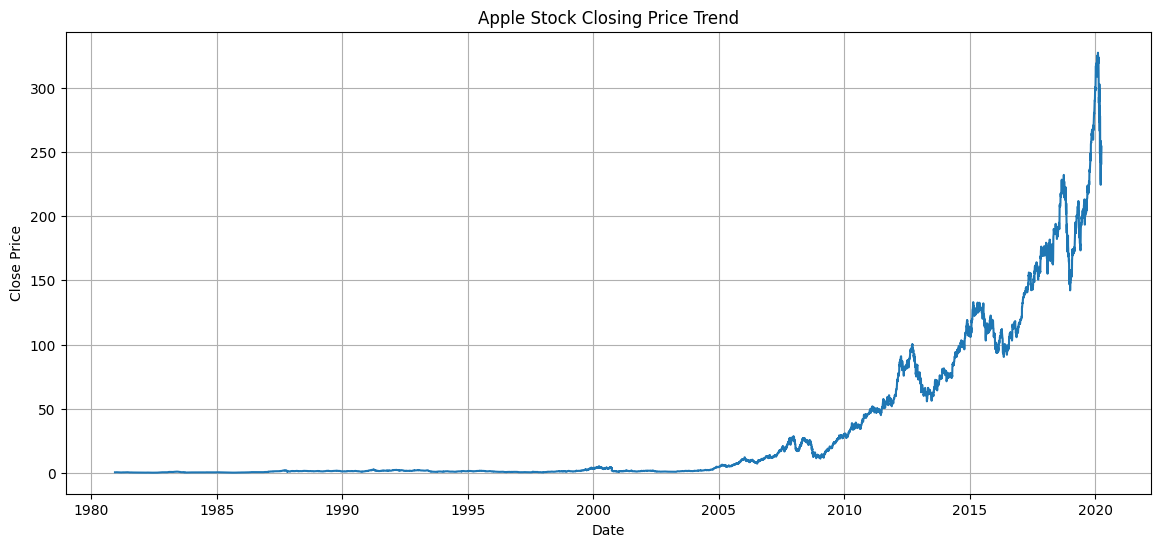

In [7]:
plt.figure(figsize=(14,6))

plt.plot(df['Close'])

plt.title("Apple Stock Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.grid(True)

plt.show()

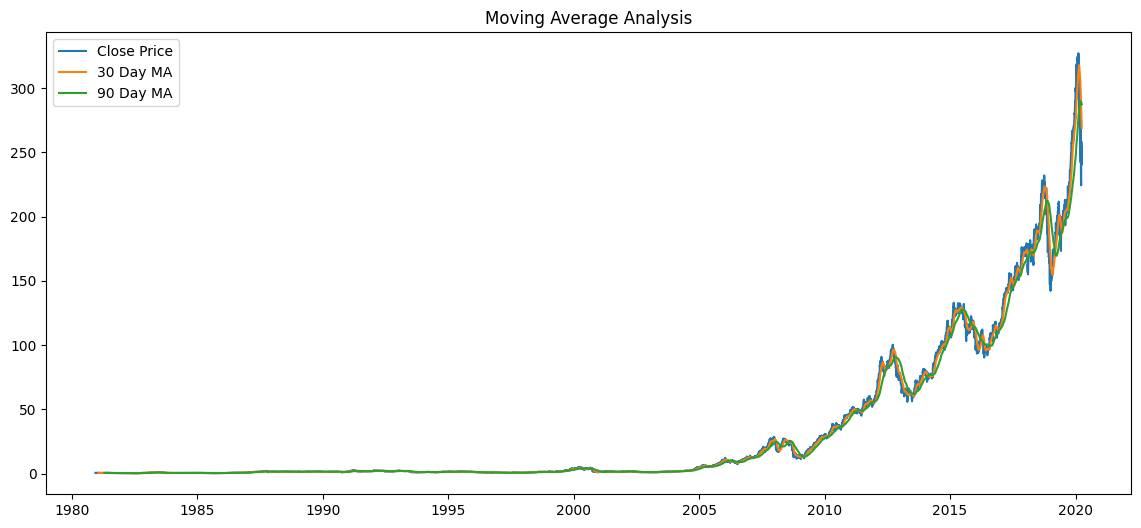

In [8]:
df['MA30'] = df['Close'].rolling(30).mean()

df['MA90'] = df['Close'].rolling(90).mean()

plt.figure(figsize=(14,6))

plt.plot(df['Close'], label='Close Price')

plt.plot(df['MA30'], label='30 Day MA')

plt.plot(df['MA90'], label='90 Day MA')

plt.legend()

plt.title("Moving Average Analysis")

plt.show()

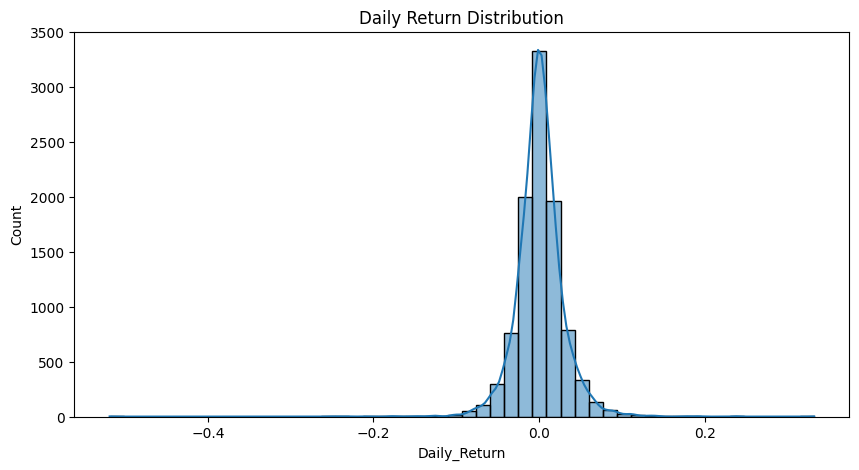

In [9]:
df['Daily_Return'] = df['Close'].pct_change()

plt.figure(figsize=(10,5))

sns.histplot(
    df['Daily_Return'].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")

plt.show()

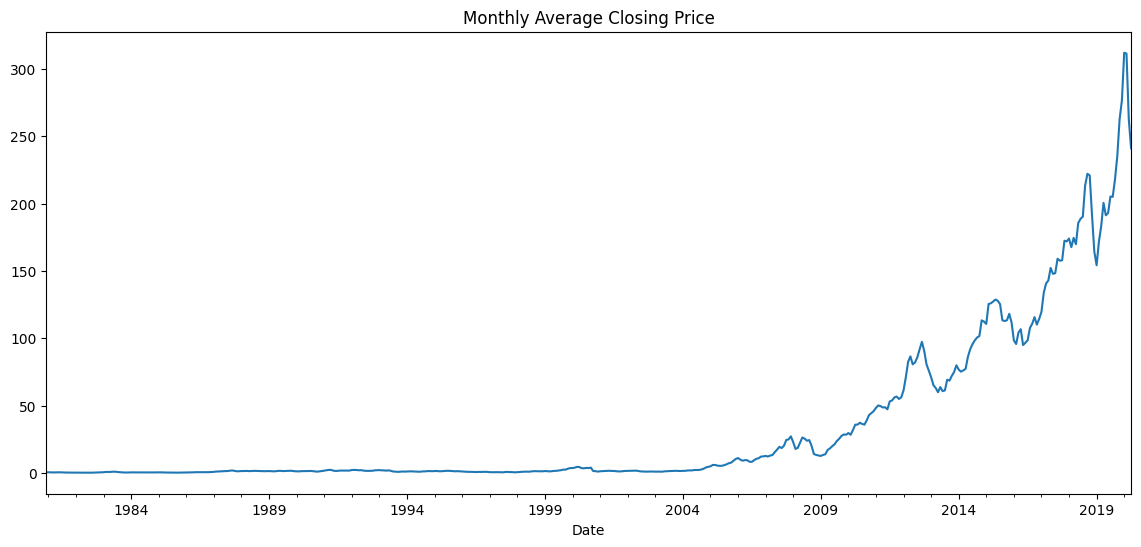

In [10]:
monthly = df['Close'].resample('M').mean()

plt.figure(figsize=(14,6))

monthly.plot()

plt.title("Monthly Average Closing Price")

plt.show()

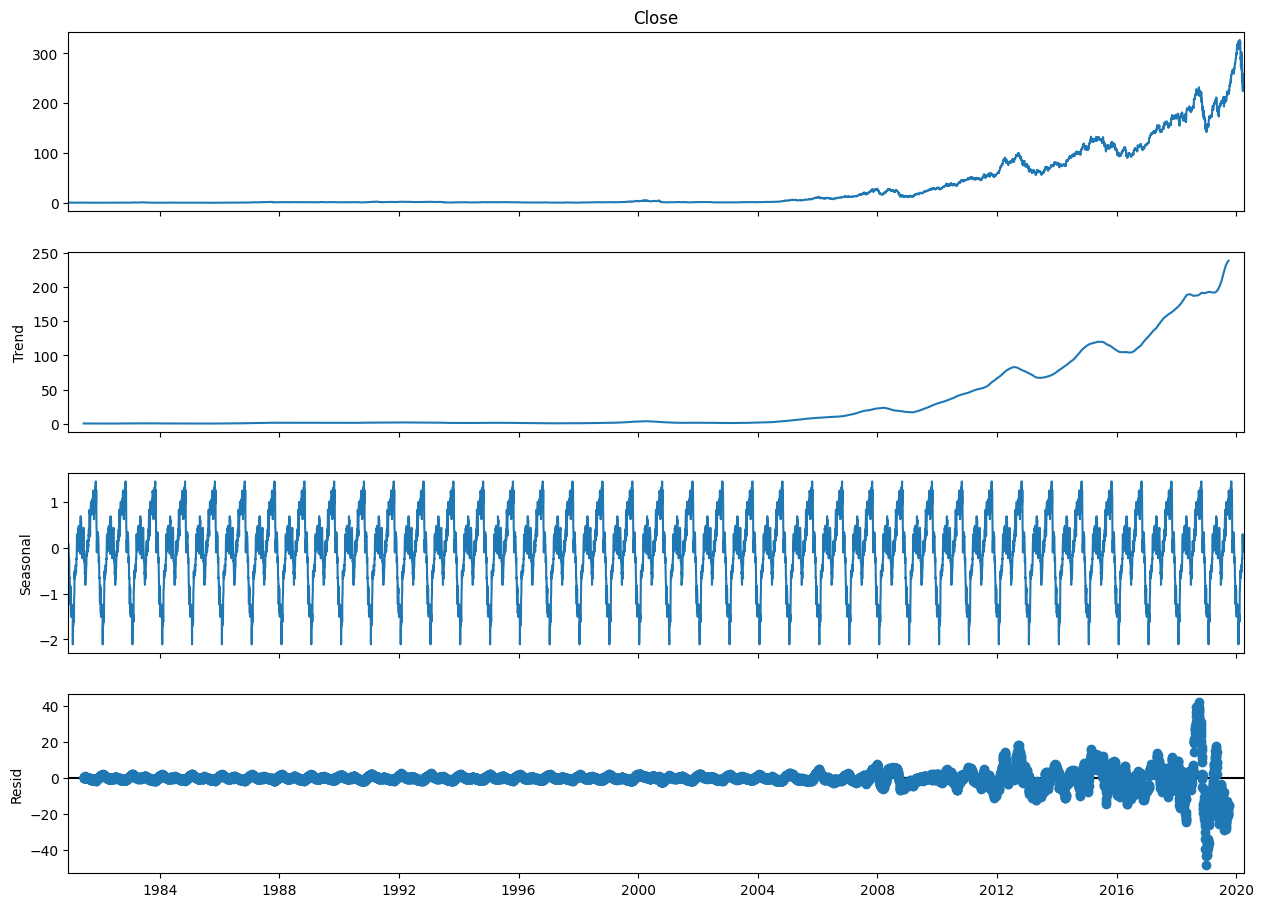

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df['Close'],
    model='additive',
    period=252
)

fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.show()

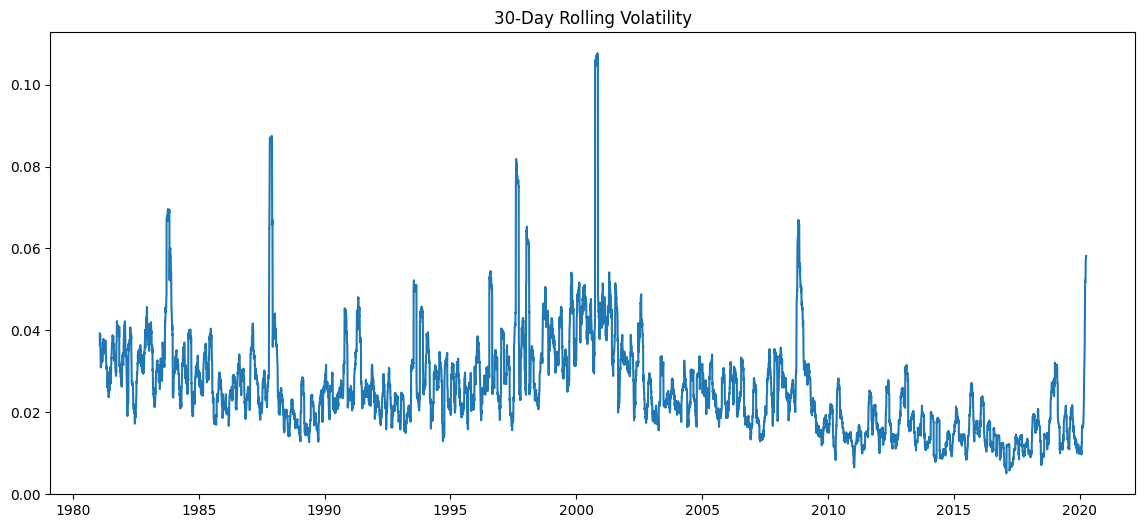

In [12]:
df['Volatility'] = (
    df['Daily_Return']
    .rolling(30)
    .std()
)

plt.figure(figsize=(14,6))

plt.plot(df['Volatility'])

plt.title("30-Day Rolling Volatility")

plt.show()

In [13]:
!pip install prophet -q

10:54:39 - cmdstanpy - INFO - Chain [1] start processing
10:54:44 - cmdstanpy - INFO - Chain [1] done processing


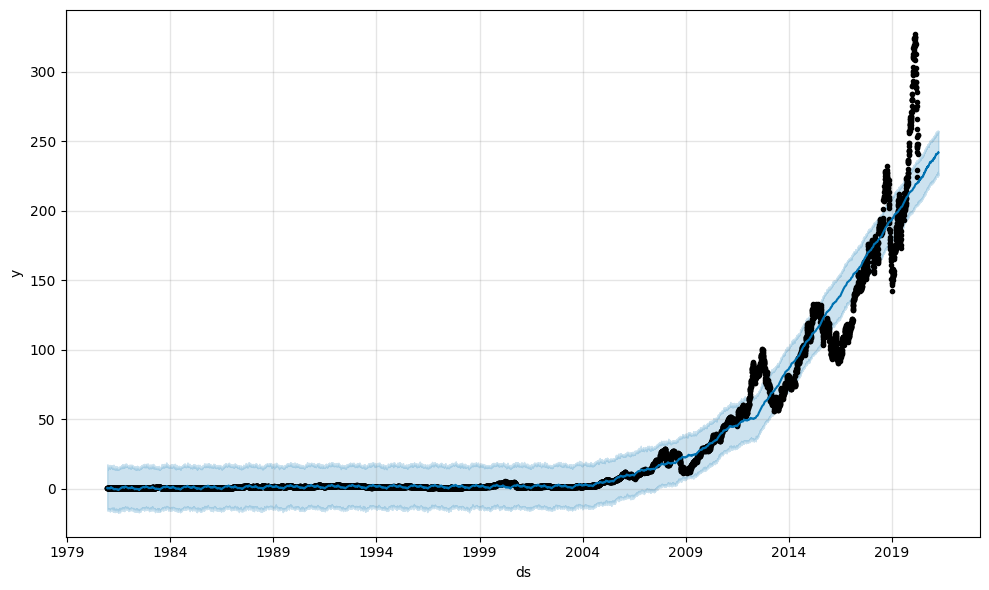

In [14]:
from prophet import Prophet

forecast_df = df.reset_index()[['Date','Close']]

forecast_df.columns = ['ds','y']

model = Prophet()

model.fit(forecast_df)

future = model.make_future_dataframe(
    periods=365
)

forecast = model.predict(future)

model.plot(forecast)

plt.show()

In [15]:
print("="*60)
print("TIME SERIES ANALYSIS REPORT")
print("="*60)

print(f"Total Records : {len(df)}")

print(f"Minimum Price : {df['Close'].min():.2f}")

print(f"Maximum Price : {df['Close'].max():.2f}")

print(f"Average Price : {df['Close'].mean():.2f}")

print("""
Insights:

1. Stock prices generally show long-term trends.

2. Moving averages smooth short-term fluctuations.

3. Seasonal decomposition identifies trend and seasonality.

4. Volatility highlights risky periods.

5. Forecasting estimates future stock behavior.

6. Monthly averages help identify long-term growth patterns.
""")

TIME SERIES ANALYSIS REPORT
Total Records : 9909
Minimum Price : 0.20
Maximum Price : 327.20
Average Price : 32.62

Insights:

1. Stock prices generally show long-term trends.

2. Moving averages smooth short-term fluctuations.

3. Seasonal decomposition identifies trend and seasonality.

4. Volatility highlights risky periods.

5. Forecasting estimates future stock behavior.

6. Monthly averages help identify long-term growth patterns.

